# STAT 207 Project 01 - Which Gaming Console has the Best Video Games?

Connor Quadrini, Akshit Makkar

### Contribution Report

<i>Connor Quadrini completed parts 1 & 4</i>

<i>Akshit Makkar completed parts 2 & 3</i>

<i>We both worked on part 5 and reviewed the full document before submission.</i>

## 1. Introduction

We chose to analyze a dataset about the sales of videogames from 2004 - 2010; it was originally used to explore the question: 'what makes a blockbuster game?' We decided to use this dataset because it was easy to access and me and my partner both play and are interested in video games. The research question we intend to answer is: What is the relationship between video game consoles and people's enjoyment of games? (Is there a console that appears to be the best?) We believe others would take interest in hearing the answer to this question because it indicates if any type gaming console is more enjoyable than others. In other words, it might show if it's a good idea to buy a game when only knwoing the console it's played on.

In [1]:
#Imports here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 2. Dataset Discussion

a. We are using the dataset provided to us from this project. The public link since is: "https://researchportal.port.ac.uk/en/datasets/video-games-dataset". No codebook is included, but the columns and rows have descriptive variable names so it's simple to understand.

b. While we can't say for how the data for this dataset was collected since the csv file was provided to us, we can assume that data about video game sales, reviews, and publisher information was collected to create this dataset.

c. In coding spaces

d. Each video game title is the unit of observation as each row has a different, specific one.

e. Console (categorical) - the name of the game console used for the video game review score.
Review Score (quantitative): an integer that represents a rating out of 100 for the game title listed.

f. One limitation I immediately noticed is that the dataset only covers games between 2004-2010. This means we can only make conclusions within
2004-2010 based on this dataset unless we add more recent or past years. Also, there's a "YearRelease" column and a column with the individual years with a logical variable system. This is practically repetitive as they both tell the same information but adds a considerable amount of columns.


In [145]:
df = pd.read_csv("video_games.csv", encoding = "unicode-escape")
df

,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1765,PlayStation 3,MotoGP 09/10,0.04,0,0,0,0,2010,0,0,...,0,0,0,0,1,0,0,0,0,1
1766,PlayStation 3,Prison Break: The Conspiracy,0.04,0,0,0,0,2010,0,0,...,0,0,0,0,0,0,0,0,0,1
1767,Nintendo Wii,"Sakura Wars: So Long, My Love",0.04,0,0,0,0,2010,0,0,...,0,0,0,0,0,0,0,0,0,1
1768,X360,Record of Agarest War (The Really Naughty Limi...,0.04,0,0,0,0,2010,0,0,...,0,0,0,0,0,0,1,0,0,0


In [146]:
df.head(10)

,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1
5,Nintendo DS,The Urbz: Sims in the City,0.41,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,1,0,0,0
6,Sony PSP,Ridge Racer,0.36,0,0,0,0,2004,1,0,...,0,0,0,0,1,0,0,0,0,1
7,Sony PSP,Metal Gear Ac!d,0.34,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
8,Nintendo DS,Madden NFL 2005,0.25,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
9,Nintendo DS,Pokmon Dash,0.22,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,1,1


In [147]:
df.shape #shape

(1770, 166)

In [148]:
df["Review Score"].value_counts() #First observation: Review scores in order of frequency

Review Score
72    62
73    61
75    60
80    56
70    56
      ..
12     1
32     1
20     1
26     1
17     1
Name: count, Length: 77, dtype: int64

In [149]:
df["Review Score"].describe() #observations 2-6: mean, standard deviation, median, and max/min values of the review scores of all the video games

count    1770.000000
mean       68.428814
std        13.894937
min        12.000000
25%        60.000000
50%        70.000000
75%        79.000000
max        98.000000
Name: Review Score, dtype: float64

## 3. Dataset Cleaning

The dataset has no missing values according to Python. After looking further into the dataset, there appears to be no implicit missing values either. There's a lot of logical variables with a bunch of 0s but these mean "false" so we can't consider these as missing values.

We did not observe any uncommon data in the categorical variables. The video game titles are all actual titles, as well as the consoles. Some titles appear more than once but this is because the game is available on multiple consoles which is completely normal. We did not observe any uncommon data in the quantitative variables. Some columns such as US sales and Review Score have a variety of floats which makes sense as every game will typically have their own unique review score and sales revenue. Other columns like the game genres are a logical variable where 0 = false, and 1 = true. While there a ton of zeros in these columns, they are representative of "false" so these are not uncommon values. We dropped 0 observations. There's no observations out of the ordinary, we used built in functions such as value_counts and describe to look out for any outliers.

We removed columns 2004 - 2010 as they represented the same information as the YearReleased column. We confirmed this by checking if the value in the YearRelease column had a "1" in the column of the numerical year, which it did. This helps us simplify this lengthy dataset a little more without compromising any essential data. Additionally, we removed some genre columns as well because there is already a designated column named "genres" that lists the basic genres of the video game title.


In [150]:
df.isna().sum()

Console                0
Title                  0
US Sales (millions)    0
Block4                 0
Block2                 0
                      ..
Platform               0
Isometric              0
SideScrolling          0
TopDown                0
ThirdPerson            0
Length: 166, dtype: int64

In [151]:
df["YearReleased"].value_counts()

YearReleased
2007    465
2008    444
2009    321
2006    294
2005    150
2010     73
2004     23
Name: count, dtype: int64

In [152]:
df["US Sales (millions)"].value_counts()

US Sales (millions)
0.05    75
0.10    67
0.09    64
0.07    61
0.06    60
        ..
1.62     1
1.44     1
1.29     1
3.30     1
2.65     1
Name: count, Length: 225, dtype: int64

In [153]:
df["Title"].value_counts()

Title
The Simpsons Game                            5
MX vs. ATV Untamed                           5
Harry Potter and the Order of the Phoenix    5
Iron Man                                     5
LEGO Batman: The Videogame                   5
                                            ..
Ridge Racer                                  1
Metal Gear Ac!d                              1
Madden NFL 2005                              1
Pokmon Dash                                 1
Dynasty Warriors                             1
Name: count, Length: 1296, dtype: int64

In [154]:
df["Console"].value_counts()

Console
X360             437
Nintendo DS      418
PlayStation 3    312
Sony PSP         307
Nintendo Wii     296
Name: count, dtype: int64

In [155]:
df[df["Title"] == "Spider-Man 3"]

,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
466,Sony PSP,Spider-Man 3,0.01,0,0,0,0,2006,0,0,...,0,0,0,0,0,0,0,0,0,1
563,X360,Spider-Man 3,0.50,0,0,0,1,2007,0,0,...,0,0,0,0,0,0,0,0,0,1
583,Nintendo Wii,Spider-Man 3,0.45,0,0,0,0,2007,0,0,...,0,0,0,0,0,0,0,0,0,1
586,Nintendo DS,Spider-Man 3,0.44,0,0,0,0,2007,0,0,...,0,0,0,0,0,1,0,1,0,0
669,PlayStation 3,Spider-Man 3,0.27,0,0,0,0,2007,0,0,...,0,0,0,0,0,0,0,0,0,1


In [156]:
df["Platform"].value_counts()

Platform
0    1616
1     154
Name: count, dtype: int64

In [2]:
df_simple = df.copy()
df_simple = df_simple.drop(columns = ["2004", "2005", "2006", "2007", "2008", "2009", "2010", "Action", "Sports", "Strategy", "RPG", "Racing", "Simulation"])
df_simple

NameError: name 'df' is not defined

## 4. Summarizing Data

Our research question is: What is the relationship between video game consoles and people's enjoyment of games?
In terms of the dataset, this is equivalent to: What is the relationship between Consoles and Review Score?

<Axes: xlabel='Console'>

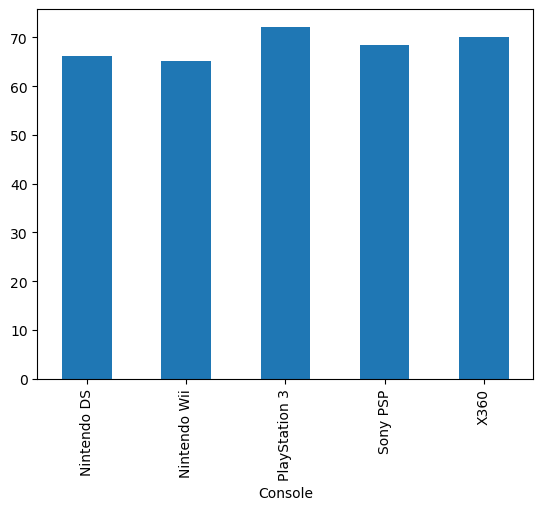

In [165]:
df_simple.groupby('Console')['Review Score'].mean().plot(kind='bar')


In [3]:
df_simple.groupby('Console')['Review Score'].describe()

NameError: name 'df_simple' is not defined

In the visualization and numerical summary, there is not a strong pattern that relates consoles to higher or lower review scores. After all, the average review score of the consoles are contained within same 6-7 points of each other, which in my opinion is not extremely significant. The statistics of mean, median and standard deviation are all comparable, but maximum and minimum values aren't as close due to outliers. It is important to note that the Nintedo DS and Xbox 360 both have around 100 more games in the dataset than the other consoles.

To answer our research question, the PlayStation 3 emerges on top in terms of average and median review scores. However, I don't think the evidence is strong enough to make the arguement that it has the best games, since the statistics are similar across all consoles. Therefore, there does not appear to be a console that objectively makes the best games.

## 5. Conclusion

Overall, you can rest assured that no one console makes more enjoyable games than the others, since there was not a significant correlation between gaming consoles and the review score of games. It should be noted that this conclusion was drawn from data from 2004 - 2010, so this statement could be inaccurate in terms of todays games. Nonetheless, games are created by developers and other companys, usually not by the companies of their consoles. In other words, all consoles have good and bad games, so other factors must contribute to their quality.

A challenge we faced in this data analysis was that this dataset was huge due to the vast amount of topics/genres in the dataset and the number of titles. We dealt with this by simplifying the dataset as much as we could by removing repetetive columns as explained in part 3.
The biggest piece of contextual information users of the dataset need to know before making any conclusions is, again, that this data is only from video games released from 2004-2010. This means we can't make claims for all video games as this is a small time frame. Additionally, the sales are based on figures only from the US, so we can't make any claims on worldwide sales using this dataset either.

If people in the future use this dataset to perform data analysis, one research question that could be looked into is "Is there a relationship between US sales and review scores?". Another possible question is: "Do certain genres consistently generate higher US sales than others?"

